In [1]:
import matplotlib.pyplot as plt
import numpy as np

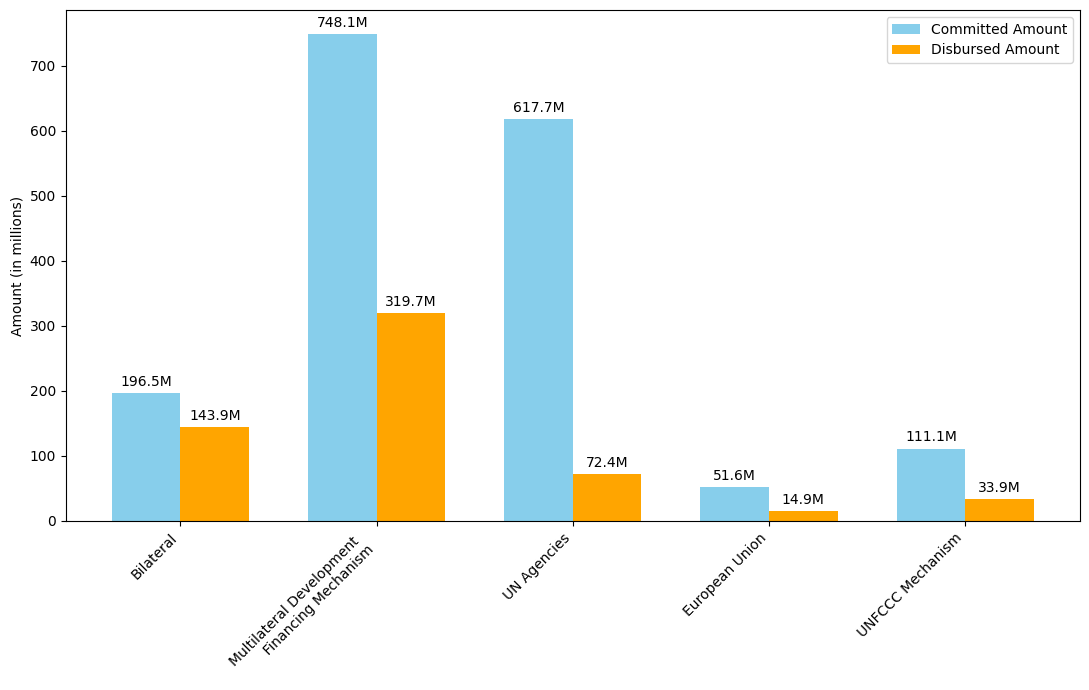

In [3]:
# Data for committed vs disbursed
sources = ["Bilateral",  "Multilateral Development \n Financing Mechanism", "UN Agencies", "European Union","UNFCCC Mechanism",]
committed = [196466945, 748079988, 617677883, 51573719, 111111462]
disbursed = [143896175,  319652529, 72395555, 14913673, 33858874]

# Convert to millions
committed_millions = [value / 1e6 for value in committed]
disbursed_millions = [value / 1e6 for value in disbursed]

# Plotting
fig, ax = plt.subplots(figsize=(11, 7))
x = np.arange(len(sources))  # the label locations
width = 0.35  # the width of the bars

# Bars for committed and disbursed
bars1 = ax.bar(x - width/2, committed_millions, width, label='Committed Amount', color='skyblue')
bars2 = ax.bar(x + width/2, disbursed_millions, width, label='Disbursed Amount', color='orange')

# Add labels, title, and legend
ax.set_ylabel("Amount (in millions)")
ax.set_xticks(x)
ax.set_xticklabels(sources, rotation=45, ha='right')
ax.legend()

# Annotate bars
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}M',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom')

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}M',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom')

plt.tight_layout()
plt.savefig('Committed vs Disbursed')
plt.show()

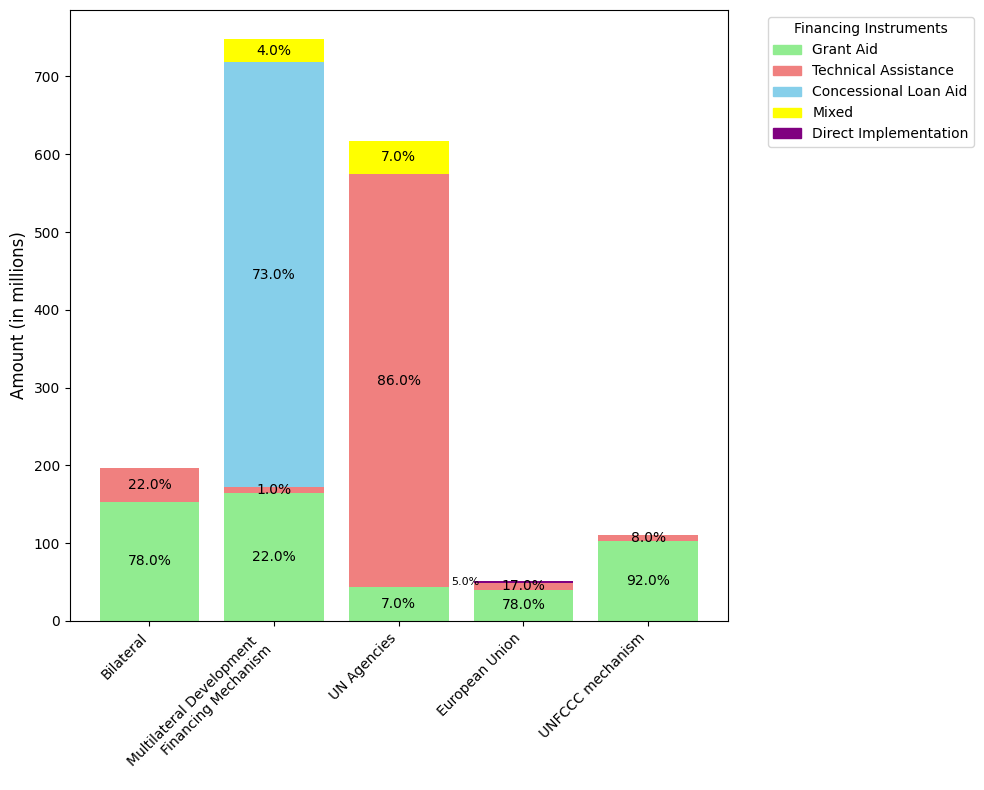

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Placeholder data
sources = ["Bilateral", "Multilateral Development \nFinancing Mechanism", "UN Agencies", "European Union", "UNFCCC mechanism"]
amount_committed = [196466945, 748079988, 617677883, 51573719, 111111462]  # Example values

instruments = [
    {"Grant Aid": 0.78, "Technical Assistance": 0.22},
    {"Grant Aid": 0.22, "Technical Assistance": 0.01, "Concessional Loan Aid": 0.73, "Mixed": 0.04},
    {"Grant Aid": 0.07, "Technical Assistance": 0.86, "Mixed": 0.07},
    {"Grant Aid": 0.78, "Technical Assistance": 0.17, "Direct Implementation": 0.05},
    {"Grant Aid": 0.92, "Technical Assistance": 0.08},

]

colors = {
    "Grant Aid": "#91ec90",
    "Technical Assistance": "#f0807f",
    "Concessional Loan Aid": "#86cfea",
    "Mixed": "#ffff00",
    "Direct Implementation": "purple"
}

fig, ax = plt.subplots(figsize=(10, 8))
x = np.arange(len(sources))

for i, source in enumerate(sources):
    bottom = 0
    for instrument, fraction in instruments[i].items():
        height = fraction * amount_committed[i] / 1e6
        ax.bar(x[i], height, bottom=bottom, color=colors[instrument], label=instrument if i == 0 else "")
        
        # Annotate percentage on each segment
        percentage = fraction * 100
        if i <4 and instrument == "Direct Implementation" :  # Combine TA and Direct Implementation for EU
            ax.text(x[i] - .35, bottom + height / 2, "5.0%", ha='right', va='center', fontsize=8)
        else:
            ax.text(x[i], bottom + height / 2, f'{percentage:.1f}%', ha='center', va='center', fontsize=10)
        
        bottom += height

# Titles and labels
ax.set_ylabel("Amount (in millions)", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(sources, rotation=45, ha='right', fontsize=10)

# Legend
handles = [plt.Rectangle((0, 0), 1, 1, color=colors[key]) for key in colors.keys()]
ax.legend(handles, colors.keys(), loc="upper left", bbox_to_anchor=(1.05, 1), title="Financing Instruments")

plt.tight_layout()
plt.savefig("Instruments")
plt.show()
